ACTIVIDAD 1
- Crear un conjunto de al menos 8 datos de dimensión 2 en los que se vean 2 grupos.
- Graficar los datos en un plano bidimensional.
- Implementar el algoritmo k-means para descubrir los 2 clusters (D=2, K=2). Almacenar los centros de cluster en una matriz (¿de qué dimensiones?) y - ofrecer como resultado también a qué cluster pertenece cada dato en otra matriz (¿de qué dimensiones?).
- Graficar los datos con colores diferentes para cada cluster.
- Pensar cómo generalizaría (qué tendría que variar en la implementación) para considerar más dimensiones D en los datos y más clusters K.

In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np

In [26]:
# Creamos el conjunto de datos N=8 datos y dimensión 2.
N = 8

datos = np.array([[0.80009759, 0.10747502],
 [0.57587823, 0.98757342],
 [0.69091741, 0.92650313],
 [0.51402127, 0.86286927],
 [0.99497492, 0.28354043],
 [0.45354275, 0.44564129],
 [0.42524214, 0.18070722],
 [0.2842815,  0.62972922]])

print('\n', datos)

print('\n', datos.ndim)

print('\n', datos.shape)


 [[0.80009759 0.10747502]
 [0.57587823 0.98757342]
 [0.69091741 0.92650313]
 [0.51402127 0.86286927]
 [0.99497492 0.28354043]
 [0.45354275 0.44564129]
 [0.42524214 0.18070722]
 [0.2842815  0.62972922]]

 2

 (8, 2)


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


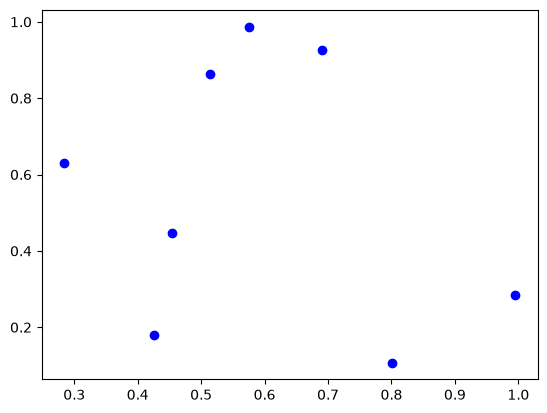

In [5]:
import matplotlib.pyplot as plt

# Almacenamos en dos variables los datos de la matriz para el valor de X como la primer columna e Y como la segunda.
X = datos[:, 0]
Y = datos[:, 1]

fig, axes = plt.subplots()

axes.plot(X, Y, 'bo', label='Datos')

plt.show()

In [44]:
# Implementación del algoritmo K-means.

# En nuestro caso K = 3 clusters.
K = 3

# 1° Init C1, C2, C3. La matriz de centros de clusters es de dimensiones K x D
C = np.array([[0.35, 0.4], 
     [0.6, 0.9],
     [0.9, 0.2]])

# Definimos la distancia euclediana entre dos puntos P1(x1,y1) y P2(x2,y2) ó generalizado para D dimensiones
def distancia_euclediana(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))
    
# Inicializamos la matriz distancia con todos ceros.
dist = np.zeros((N, K), dtype=float)

# 2° Poblamos la matriz con la distancia de cada punto a cada cluster.
for i in range(N):
    for j in range(K):
        dist[i, j] = distancia_euclediana(datos[i, :], C[j, :])

print("\n Matriz distancia =")
print(f"C1 \t\t C2 \t\t C3")
print(dist)

# Calculamos la matriz de pertenencia
pert = np.zeros((N, K), dtype=int)

for i in range(N):
    indice_min = np.argmin(dist[i,:], axis=0)
    pert[i, indice_min] = 1

print("\nMatriz pertenencia =")
print(pert)


 Matriz distancia =
C1 		 C2 		 C3
[[0.53680416 0.81739519 0.13616668]
 [0.62949464 0.09083482 0.85166121]
 [0.62724017 0.09470159 0.75599096]
 [0.49107121 0.09365379 0.76705622]
 [0.65540482 0.73213905 0.1264881 ]
 [0.11315577 0.47737989 0.50957209]
 [0.23184198 0.74021781 0.4751497 ]
 [0.23894442 0.41560133 0.7508505 ]]

Matriz pertenencia =
[[0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [1 0 0]]


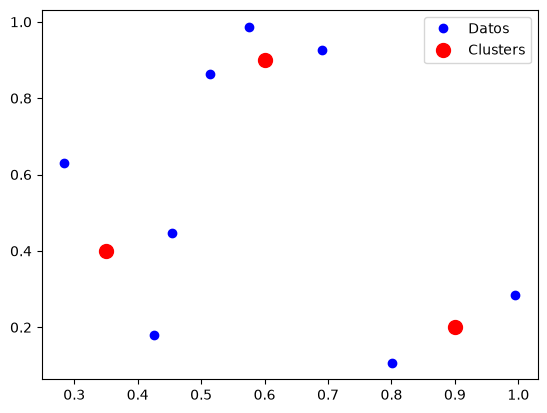

In [45]:
CX = C[:, 0]
CY = C[:, 1]

fig, axes = plt.subplots()

axes.plot(X, Y, 'bo', label='Datos')

axes.plot(CX, CY, 'ro', markersize=10, label='Clusters')

axes.legend()
plt.show()

In [47]:
# 3° Recalculamos los Ck

dist_old = np.zeros((N, K), dtype=float)

while not np.allclose(dist, dist_old, atol=0.01, rtol=0):
    dist_old = dist.copy()

    # Recalculamos los centroides
    for j in range(K):
        prom = np.zeros(2, dtype=float)
        cant = 0

        for i in range(N):
            if pert[i, j] == 1:
                print(f"Para cluster {j} se asigna el punto {datos[i, :]}")
                prom += datos[i, :]
                cant += 1

        if cant > 0:
            C[j, :] = prom / cant
        else:
            print(f"El cluster {j} quedó vacío")

    # Recalculamos las distancias usando los nuevos centroides
    for i in range(N):
        for j in range(K):
            dist[i, j] = distancia_euclediana(datos[i, :], C[j, :])
            
    # Recalculamos la matriz de pertenencia
    pert[:] = 0
    for i in range(N):
        indice_min = np.argmin(dist[i,:], axis=0)
        pert[i, indice_min] = 1

print(f"\nC = {C}")
print(f"\n pert = \n {pert}")

Para cluster 0 se asigna el punto [0.45354275 0.44564129]
Para cluster 0 se asigna el punto [0.42524214 0.18070722]
Para cluster 0 se asigna el punto [0.2842815  0.62972922]
Para cluster 1 se asigna el punto [0.57587823 0.98757342]
Para cluster 1 se asigna el punto [0.69091741 0.92650313]
Para cluster 1 se asigna el punto [0.51402127 0.86286927]
Para cluster 2 se asigna el punto [0.80009759 0.10747502]
Para cluster 2 se asigna el punto [0.99497492 0.28354043]
Para cluster 0 se asigna el punto [0.45354275 0.44564129]
Para cluster 0 se asigna el punto [0.42524214 0.18070722]
Para cluster 0 se asigna el punto [0.2842815  0.62972922]
Para cluster 1 se asigna el punto [0.57587823 0.98757342]
Para cluster 1 se asigna el punto [0.69091741 0.92650313]
Para cluster 1 se asigna el punto [0.51402127 0.86286927]
Para cluster 2 se asigna el punto [0.80009759 0.10747502]
Para cluster 2 se asigna el punto [0.99497492 0.28354043]

C = [[0.3876888  0.41869258]
 [0.59360564 0.92564861]
 [0.89753626 0.19

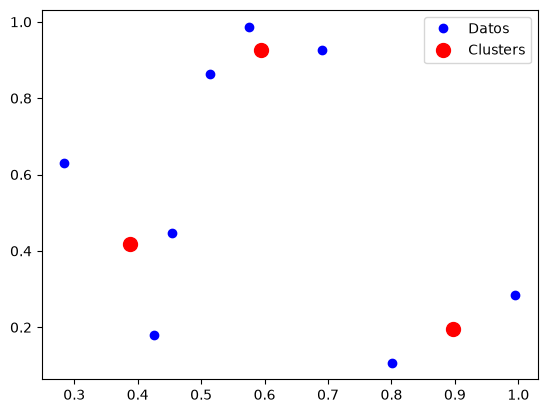

In [48]:
CX = C[:, 0]
CY = C[:, 1]

fig, axes = plt.subplots()

axes.plot(X, Y, 'bo', label='Datos')

axes.plot(CX, CY, 'ro', markersize=10, label='Clusters')

axes.legend()
plt.show()

# Resumen de dimensiones

| Variable | Dimensión | Significado |
|---|---:|---|
| `datos` | $N \times D$ | Los `N` datos con `D` características |
| `C` | $K \times D$ | Los centroides de los `K` clústeres |
| `dist` | $N \times K$ | Distancia de cada dato a cada centroide |
| `pert` | $N \times K$ | Pertenencia de cada dato a cada clúster |